In [7]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, f1_score, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

sys.path.append(os.path.abspath('..'))
from notebook_utils import setup_env, load_data_for_modeling

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

PROJECT_ROOT, config = setup_env()
MODELS_DIR = PROJECT_ROOT / config['paths']['models']
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Модели сохраняем в: {MODELS_DIR}")

Using device: cpu
Модели сохраняем в: D:\Education\Arcticle\dtp_project\data\models


In [8]:
df = load_data_for_modeling(config, PROJECT_ROOT, fill_cats=True)

target_col = config['features']['target_col']
cat_cols = config['features']['cat_cols']
# Определяем числовые колонки (все, что не таргет и не кат)
num_cols = [c for c in df.columns if c not in cat_cols and c != target_col]

print(f"Categorical features: {len(cat_cols)}")
print(f"Numerical features: {len(num_cols)}")

Загрузка данных из: D:\Education\Arcticle\dtp_project\data\processed\dtp_full_dataset.parquet
Режим таргета: binary_severe. Распределение:
target
0    0.6065
1    0.3935
Name: proportion, dtype: float64
Categorical features: 4
Numerical features: 83


In [9]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].values

# Label Encoding для категорий
cat_dims = [] # Здесь будем хранить размерность каждой категории (сколько уникальных значений)
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Приводим к строке для надежности
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    # +1 для обработки неизвестных значений в будущем (optional, но полезно)
    cat_dims.append(len(le.classes_))

# Scaling для чисел
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Превращаем в numpy arrays для Datasets
X_train_cat = X_train[cat_cols].values.astype(np.int64)
X_train_num = X_train[num_cols].values.astype(np.float32)
y_train = y_train.astype(np.float32)

X_test_cat = X_test[cat_cols].values.astype(np.int64)
X_test_num = X_test[num_cols].values.astype(np.float32)
y_test = y_test.astype(np.float32)

In [10]:
class DTPSeverityDataset(Dataset):
    def __init__(self, x_cat, x_num, y):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # [Batch, 1]
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.x_cat[idx], self.x_num[idx], self.y[idx]

train_dataset = DTPSeverityDataset(X_train_cat, X_train_num, y_train)
test_dataset = DTPSeverityDataset(X_test_cat, X_test_num, y_test)

BATCH_SIZE = 512 # Для табличных данных можно брать большой батч

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
class TabularModel(nn.Module):
    def __init__(self, cat_dims, num_features, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()
        
        # --- Embeddings Layer ---
        # Правило большого пальца для размера эмбеддинга: min(50, (x + 1) // 2)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=min(50, (dim + 1) // 2))
            for dim in cat_dims
        ])
        
        # Считаем общий размер вектора после объединения всех эмбеддингов
        total_emb_dim = sum([min(50, (dim + 1) // 2) for dim in cat_dims])
        input_dim = total_emb_dim + num_features
        
        # --- MLP Layers ---
        layers = []
        curr_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.BatchNorm1d(curr_dim)) # BatchNorm помогает табличкам учиться стабильнее
            layers.append(nn.Linear(curr_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            curr_dim = hidden_dim
            
        self.mlp = nn.Sequential(*layers)
        
        # --- Output Layer ---
        self.output = nn.Linear(curr_dim, 1) # Бинарная классификация
        
    def forward(self, x_cat, x_num):
        # Прогоняем категории через эмбеддинги
        emb_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            emb_outputs.append(emb_layer(x_cat[:, i]))
            
        # Конкатенируем эмбеддинги
        x_emb = torch.cat(emb_outputs, dim=1)
        
        # Конкатенируем с числовыми данными
        x = torch.cat([x_emb, x_num], dim=1)
        
        # MLP
        x = self.mlp(x)
        
        # Logits (сигмоиду применим в loss функции или при предикте)
        return self.output(x)

# Инициализация модели
model = TabularModel(
    cat_dims=cat_dims,
    num_features=len(num_cols),
    hidden_dims=[512, 256, 128], # Чуть пошире слои
    dropout=0.3
).to(DEVICE)

In [12]:
# Веса классов для Loss (аналог scale_pos_weight)
# Считаем вручную: (кол-во 0) / (кол-во 1)
pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Встроенная сигмоида + веса
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2, steps_per_epoch=len(train_loader), epochs=15
)

def train_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss = 0
    
    for x_cat, x_num, y in loader:
        x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x_cat, x_num)
        loss = criterion(outputs, y)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    preds = []
    targets = []
    
    with torch.no_grad():
        for x_cat, x_num, y in loader:
            x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
            outputs = model(x_cat, x_num)
            
            # Применяем сигмоиду для вероятностей
            probs = torch.sigmoid(outputs)
            preds.extend(probs.cpu().numpy())
            targets.extend(y.cpu().numpy())
            
    return np.array(targets), np.array(preds)

EPOCHS = 15
history = {'train_loss': [], 'val_auc': []}
best_auc = 0

print(f"Start training for {EPOCHS} epochs on {DEVICE}...")

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler)
    
    y_true, y_prob = evaluate(model, test_loader)
    val_auc = roc_auc_score(y_true, y_prob)
    
    history['train_loss'].append(train_loss)
    history['val_auc'].append(val_auc)
    
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), MODELS_DIR / "best_neural_net.pth")
        
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

Start training for 15 epochs on cpu...
Epoch 1/15 | Loss: 0.7663 | Val AUC: 0.7224
Epoch 2/15 | Loss: 0.7433 | Val AUC: 0.7273
Epoch 3/15 | Loss: 0.7395 | Val AUC: 0.7287
Epoch 4/15 | Loss: 0.7342 | Val AUC: 0.7321
Epoch 5/15 | Loss: 0.7284 | Val AUC: 0.7364
Epoch 6/15 | Loss: 0.7212 | Val AUC: 0.7339
Epoch 7/15 | Loss: 0.7155 | Val AUC: 0.7362
Epoch 8/15 | Loss: 0.7100 | Val AUC: 0.7369
Epoch 9/15 | Loss: 0.7006 | Val AUC: 0.7341
Epoch 10/15 | Loss: 0.6917 | Val AUC: 0.7317
Epoch 11/15 | Loss: 0.6791 | Val AUC: 0.7304
Epoch 12/15 | Loss: 0.6624 | Val AUC: 0.7269
Epoch 13/15 | Loss: 0.6462 | Val AUC: 0.7219
Epoch 14/15 | Loss: 0.6305 | Val AUC: 0.7217
Epoch 15/15 | Loss: 0.6221 | Val AUC: 0.7210


=== Neural Network Results ===
Best ROC AUC: 0.7369
F1 Macro:     0.6611

Report:
              precision    recall  f1-score   support

         0.0       0.77      0.64      0.70     20311
         1.0       0.56      0.70      0.62     13179

    accuracy                           0.67     33490
   macro avg       0.66      0.67      0.66     33490
weighted avg       0.69      0.67      0.67     33490



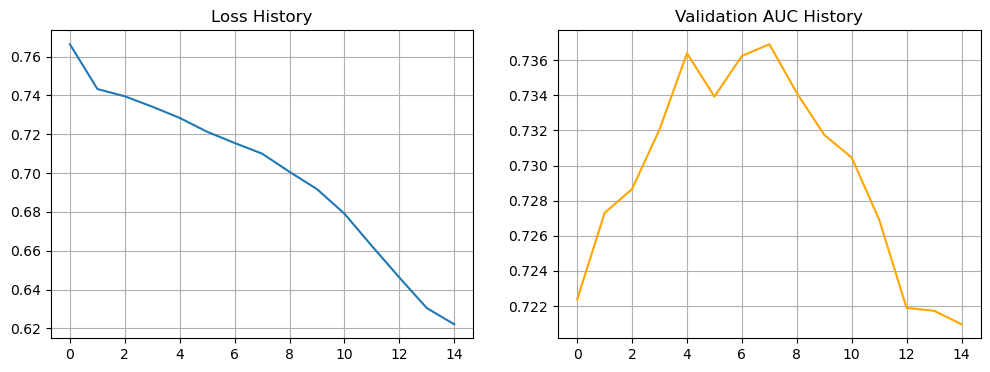

In [18]:
model.load_state_dict(torch.load(MODELS_DIR / "best_neural_net.pth", weights_only=True))
model.eval()

y_true, y_prob = evaluate(model, test_loader)
y_pred = (y_prob >= 0.5).astype(int)

print("=== Neural Network Results ===")
print(f"Best ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"F1 Macro:     {f1_score(y_true, y_pred, average='macro'):.4f}")
print("\nReport:")
print(classification_report(y_true, y_pred))

# Графики обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Loss History')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='Val AUC', color='orange')
plt.title('Validation AUC History')
plt.grid(True)
plt.show()

--- Вычисление важности признаков (Permutation Importance) ---
Baseline AUC: 0.73690


100%|██████████████████████████████████████████████████████████████████████████████████| 87/87 [00:14<00:00,  5.87it/s]
C:\Users\danii\AppData\Local\Temp\ipykernel_19720\3226886191.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perm_df.head(top_n), x='Importance', y='Feature', palette='viridis')


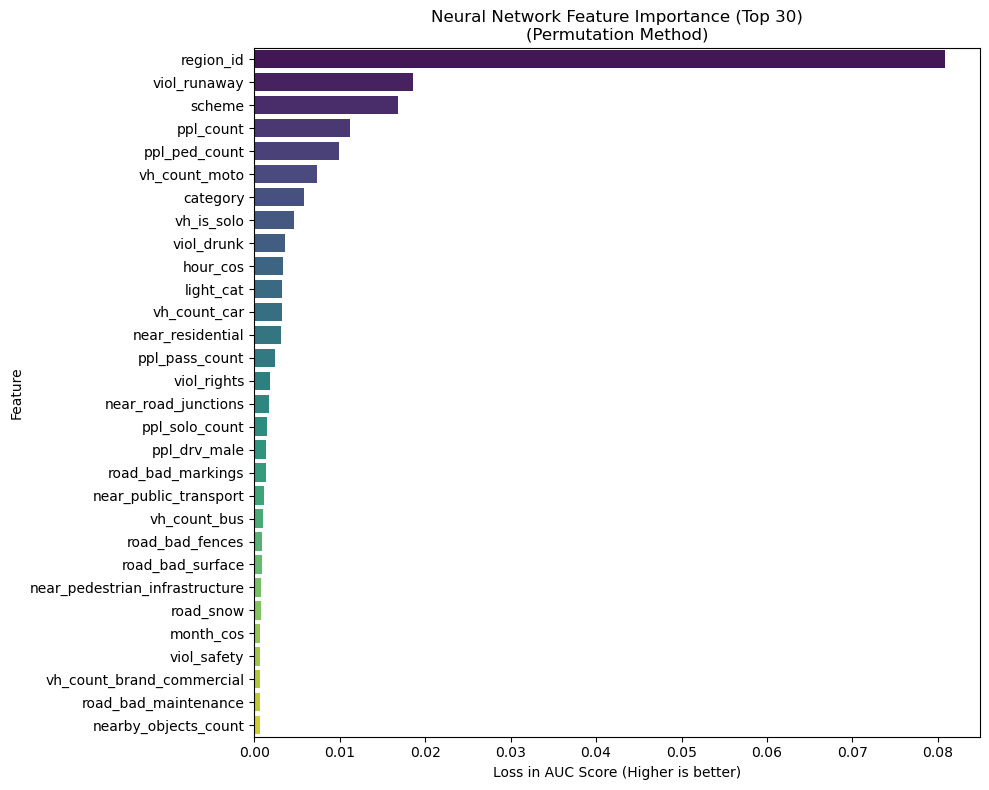

Top 10 Most Important Features:
                   Feature  Importance
0                region_id    0.080887
85            viol_runaway    0.018633
2                   scheme    0.016844
68               ppl_count    0.011250
70           ppl_ped_count    0.009918
..                     ...         ...
34         road_bad_lights   -0.000054
61  vh_count_brand_premium   -0.000072
41                road_ice   -0.000224
73     ppl_ped_other_count   -0.000240
6                 hour_sin   -0.000447

[87 rows x 2 columns]


In [21]:
print("--- Вычисление важности признаков (Permutation Importance) ---")

# Функция для быстрого инференса батчами (чтобы не переполнить память)
def predict_batch_fast(model, x_cat_np, x_num_np, batch_size=2048):
    model.eval()
    probs = []
    # Конвертируем все данные в тензоры сразу, если влезают в память GPU, 
    # или делаем это внутри цикла, если данных очень много.
    # Для 33к строк можно сразу.
    with torch.no_grad():
        total_len = len(x_cat_np)
        for i in range(0, total_len, batch_size):
            x_c = torch.tensor(x_cat_np[i:i+batch_size], dtype=torch.long).to(DEVICE)
            x_n = torch.tensor(x_num_np[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            out = model(x_c, x_n)
            probs.extend(torch.sigmoid(out).cpu().numpy().flatten())
    return np.array(probs)

# 1. Базовая метрика
base_probs = predict_batch_fast(model, X_test_cat, X_test_num)
base_score = roc_auc_score(y_test, base_probs)
print(f"Baseline AUC: {base_score:.5f}")

feature_names = cat_cols + num_cols
importances = []

# 2. Цикл по признакам
for feat in tqdm(feature_names):
    # Копируем исходные массивы
    X_cat_shuffled = X_test_cat.copy()
    X_num_shuffled = X_test_num.copy()
    
    if feat in cat_cols:
        col_idx = cat_cols.index(feat)
        np.random.shuffle(X_cat_shuffled[:, col_idx]) # Перемешиваем категорию
        # Предикт на "битых" категориях
        shuffled_probs = predict_batch_fast(model, X_cat_shuffled, X_test_num)
        
    else:
        col_idx = num_cols.index(feat)
        np.random.shuffle(X_num_shuffled[:, col_idx]) # Перемешиваем число
        # Предикт на "битых" числах
        shuffled_probs = predict_batch_fast(model, X_test_cat, X_num_shuffled)
    
    # Считаем, насколько упала метрика
    shuffled_score = roc_auc_score(y_test, shuffled_probs)
    drop = base_score - shuffled_score
    importances.append(drop)

# 3. Визуализация
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
top_n = 30
sns.barplot(data=perm_df.head(top_n), x='Importance', y='Feature', palette='viridis')
plt.title(f'Neural Network Feature Importance (Top {top_n})\n(Permutation Method)')
plt.xlabel('Loss in AUC Score (Higher is better)')
plt.tight_layout()
plt.show()

In [22]:
print("Top 10 Most Important Features:")
print(perm_df.head(15))

Top 10 Most Important Features:
             Feature  Importance
0          region_id    0.080887
85      viol_runaway    0.018633
2             scheme    0.016844
68         ppl_count    0.011250
70     ppl_ped_count    0.009918
58     vh_count_moto    0.007339
3           category    0.005807
49        vh_is_solo    0.004630
82        viol_drunk    0.003571
7           hour_cos    0.003391
1          light_cat    0.003273
55      vh_count_car    0.003200
9   near_residential    0.003128
69    ppl_pass_count    0.002409
84       viol_rights    0.001782
